In [114]:
import stim
import itertools
import numpy as np

## Helper Functions

In [115]:
#####################################################################
def commute(p1: stim.PauliString, p2:stim.PauliString):
  return p1.commutes(p2)

######################################################################
def conjugate_stabilizer_by_circuit(stabilizer: stim.PauliString, circuit: stim.Circuit) -> stim.PauliString:
    """
    Conjugates a PauliString stabilizer by a stim.Circuit
    """
    if type(stabilizer) == str:
      stabilizer = stim.PauliString(stabilizer)

    tableau = circuit.to_tableau()
    conjugated_stabilizer = tableau(stabilizer)
    return conjugated_stabilizer


######################################################################
def pauli_to_xz(p: stim.PauliString) -> np.ndarray:
    """
    Convert Stim PauliString to binary symplectic vector:
        [x_0 ... x_{n-1} | z_0 ... z_{n-1}]
    """
    s = str(p)
    if s[0] in "+-":
        s = s[1:]

    x = []
    z = []

    for c in s:
        if c in "I_":
            x.append(0); z.append(0)
        elif c == "X":
            x.append(1); z.append(0)
        elif c == "Z":
            x.append(0); z.append(1)
        elif c == "Y":
            x.append(1); z.append(1)
        else:
            raise ValueError(f"Unknown Pauli char: {c}")

    return np.array(x + z, dtype=np.uint8)


######################################################################
def gf2_solve(A, b):
    """
    Solve A x = b over GF(2).
    Returns one solution x, or None if no solution.
    """
    A = A.copy() % 2
    b = b.copy() % 2

    m, n = A.shape
    aug = np.concatenate([A, b.reshape(-1, 1)], axis=1)

    pivots = []
    row = 0

    for col in range(n):
        pivot = None
        for r in range(row, m):
            if aug[r, col]:
                pivot = r
                break

        if pivot is None:
            continue

        aug[[row, pivot]] = aug[[pivot, row]]

        for r in range(m):
            if r != row and aug[r, col]:
                aug[r] ^= aug[row]

        pivots.append(col)
        row += 1

    # check inconsistency: 0 = 1
    for r in range(row, m):
        if aug[r, :-1].sum() == 0 and aug[r, -1]:
            return None

    x = np.zeros(n, dtype=np.uint8)
    for i, col in enumerate(pivots):
        x[col] = aug[i, -1]

    return x

######################################################################
def equivalent_up_to_stabilizers(
    p1: stim.PauliString,
    p2: stim.PauliString,
    stabilizers: list[stim.PauliString],
):
    """
    Checks whether p1 and p2 differ by a product of stabilizers.

    Returns:
        equivalent:       bool
        used_indices:     list[int]
        used_stabilizers: list[stim.PauliString]
        product:          stim.PauliString or None

    Meaning:
        logical_b = logical_a * product_of_used_stabilizers, up to phase.
    """

    v1 = pauli_to_xz(p1)
    v2 = pauli_to_xz(p2)
    stab_vecs = [pauli_to_xz(s) for s in stabilizers]

    if len(v1) != len(v2):
        raise ValueError("ERROR: (equivalent_up_to_stabilizers)  operators have different numbers of qubits.")

    rhs = v1 ^ v2

    if len(stab_vecs) == 0:
        return bool(np.all(rhs == 0)), [], [], stim.PauliString(len(p1))

    A = np.stack(stab_vecs, axis=1)

    coeffs = gf2_solve(A, rhs)

    if coeffs is None:
        return False, [], [], None

    used_indices      = [i for i, c in enumerate(coeffs) if c]
    used_stabilizers  = [stabilizers[i] for i in used_indices]

    prod = stim.PauliString(len(p1))
    for s in used_stabilizers:
        prod *= s

    return True, used_indices, used_stabilizers, prod


def stabilizer_span(generators):
    span = set()
    n = len(generators)

    for bits in itertools.product([0, 1], repeat=n):
        p = stim.PauliString(len(generators[0]))
        for bit, g in zip(bits, generators):
            if bit:
                p *= g
        span.add(str(p))
    return span


## 5 qubit code

In [188]:
generators_5qubits = [
    stim.PauliString("ZZXIX"), # stim.PauliString("ZXIXZ")
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"),
    stim.PauliString("XIXZZ")
]


# logical operators
logical_I = stim.PauliString("IIIII")
logical_X = stim.PauliString("XXXXX")
logical_Z = stim.PauliString("ZZZZZ")

# equivalent logical operators
logical_X_min = stim.PauliString("-YIXIY")
logical_Z_min = stim.PauliString("-XIZIX")

# test equivalency
eq, inds, seq, prod = equivalent_up_to_stabilizers(logical_Z, logical_Z_min, generators_5qubits)
if eq:
  print(f"Operators {logical_Z} and {logical_Z_min} are equivalent under multiplication by stabalizer {prod}\n",
        f"which is generated by product of generators: {[str(i) for i in seq]}")
else:
  print(f"Operators {logical_Z} and {logical_Z_min} are not equivalent")


eq, inds, seq, prod = equivalent_up_to_stabilizers(logical_X, logical_X_min, generators_5qubits)
if eq:
  print(f"Operators {logical_X} and {logical_X_min} are equivalent under multiplication by stabalizer {prod}\n",
        f"which is generated by product of generators: {[str(i) for i in seq]}")
else:
  print(f"Operators {logical_X} and {logical_X_min} are not equivalent")


Operators +ZZZZZ and -X_Z_X are equivalent under multiplication by stabalizer +YZ_ZY
 which is generated by product of generators: ['+ZZX_X', '+X_XZZ']
Operators +XXXXX and -Y_X_Y are equivalent under multiplication by stabalizer +ZX_XZ
 which is generated by product of generators: ['+ZZX_X', '+XZZX_', '+_XZZX', '+X_XZZ']


## Two Combined 5-qubit codes 

In [189]:
print("Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]")

combined_generators = []
for s in generators_5qubits:
    combined_generators.append(s+logical_I)
    combined_generators.append(logical_I+s)
    print(str(s+logical_I)+ "   " + str(logical_I+s))

combined_span = stabilizer_span(combined_generators)

logical_XI = logical_X_min + logical_I
logical_ZI = logical_Z_min + logical_I
logical_IX = logical_I + logical_X_min
logical_IZ = logical_I + logical_Z_min
logical_XX = logical_X_min + logical_X_min
logical_ZZ = logical_Z_min + logical_Z_min
logical_XZ = logical_X_min + logical_Z_min
logical_ZX = logical_Z_min + logical_X_min


Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]
+ZZX_X_____   +_____ZZX_X
+XZZX______   +_____XZZX_
+_XZZX_____   +______XZZX
+X_XZZ_____   +_____X_XZZ


In [210]:
def cyclic_shift_right(s, i):
    sign = s[0]
    s = s[1:]
    i %= len(s)
    return sign + s[-i:] + s[:-i] if i else sign+s

span = stabilizer_span(generators_5qubits)

for g in generators_5qubits:
    s0 = str(g)
    for i in range(5):
        shifted = cyclic_shift_right(s0, i)

        if shifted not in span:
            print("missing:", shifted)

## Pieceably Fault-tolerant CZ

In [19]:
##############################################################################
###########                         PROLOGUE                       ###########
##############################################################################
prologue_circuit = stim.Circuit()
prologue_circuit.append("H", [0])
prologue_circuit.append("S", [0])
prologue_circuit.append("Y", [2])
prologue_circuit.append("H", [4])
prologue_circuit.append("S", [4])
prologue_circuit.append("H", [0+5])
prologue_circuit.append("S", [0+5])
prologue_circuit.append("Y", [2+5])
prologue_circuit.append("H", [4+5])
prologue_circuit.append("S", [4+5])

combined_generators_after_prologue = [conjugate_stabilizer_by_circuit(s, prologue_circuit) for s in combined_generators]

# print("prologue circuit = KIYIK|KIYIK, with K = SH")
# print("combined generators after prologue circuit: ")
# for i in range(len(combined_generators_after_prologue)//2):
#    print(str(combined_generators_after_prologue[2*i]) + "   " + str(combined_generators_after_prologue[2*i+1]))

# print("\nCheck membership in original stabilizer group:")
# for s in combined_generators_after_prologue:
#     if str(s) in combined_span:
#         print(s, "YES")
#     else:
#         print(s, "NO")

logical_IX_after_prologue           = str(conjugate_stabilizer_by_circuit(logical_IX, prologue_circuit))
logical_IZ_after_prologue           = str(conjugate_stabilizer_by_circuit(logical_IZ, prologue_circuit))

# print("logical IX after prologue circuit = ", logical_IX_after_prologue)
# print("logical IZ after prologue circuit = ", logical_IZ_after_prologue)
# print("\n_____________________________________________________________________\n")

##############################################################################
###########                      Round Robin                       ###########
##############################################################################

round_robin_circuit = stim.Circuit()
round_robin_circuit.append("CZ", [0,5])
# round_robin_circuit.append("CZ", [0,9])
round_robin_circuit.append("SWAP", [9,5])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [9,5])

# round_robin_circuit.append("CZ", [2,5])
round_robin_circuit.append("SWAP", [0,2])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [0,2])


# round_robin_circuit.append("CZ", [2,7])
round_robin_circuit.append("SWAP", [0,2])
round_robin_circuit.append("SWAP", [5,7])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [5,7])
round_robin_circuit.append("SWAP", [0,2])


# round_robin_circuit.append("CZ", [4,7])
round_robin_circuit.append("SWAP", [0,4])
round_robin_circuit.append("SWAP", [5,7])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [5,7])
round_robin_circuit.append("SWAP", [0,4])

# round_robin_circuit.append("CZ", [4,9])
round_robin_circuit.append("SWAP", [0,4])
round_robin_circuit.append("SWAP", [5,9])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [5,9])
round_robin_circuit.append("SWAP", [0,4])


combined_generators_after_round_robin_circuit1 = [conjugate_stabilizer_by_circuit(s, round_robin_circuit) for s in combined_generators_after_prologue]
# print("combined generators after round robin circiut part (a): ")
# for i in range(len(combined_generators_after_round_robin_circuit1)//2):
#    print(str(combined_generators_after_round_robin_circuit1[2*i]) + "   " + str(combined_generators_after_round_robin_circuit1[2*i+1]))


logical_IX_after_round_robin           = str(conjugate_stabilizer_by_circuit(logical_IX_after_prologue, round_robin_circuit))
logical_IZ_after_round_robin           = str(conjugate_stabilizer_by_circuit(logical_IZ_after_prologue, round_robin_circuit))

# print("logical IX after round robin circuit = ", logical_IX_after_round_robin)
# print("logical IZ after round robin circuit = ", logical_IZ_after_round_robin)
# print("\n_____________________________________________________________________\n")

# round_robin_circuit.append("CZ", [0,7])
round_robin_circuit.append("SWAP", [7,5])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [7,5])

# round_robin_circuit.append("CZ", [2,9])
round_robin_circuit.append("SWAP", [2,0])
round_robin_circuit.append("SWAP", [9,5])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [9,5])
round_robin_circuit.append("SWAP", [2,0])

# round_robin_circuit.append("CZ", [4,5])
round_robin_circuit.append("SWAP", [4,0])
round_robin_circuit.append("CZ", [0,5])
round_robin_circuit.append("SWAP", [4,0])

combined_generators_after_round_robin_circuit = [conjugate_stabilizer_by_circuit(s, round_robin_circuit) for s in combined_generators_after_prologue]
# print("combined generators after round robin circiut part (b): ")
# for i in range(len(combined_generators_after_round_robin_circuit)//2):
#    print(str(combined_generators_after_round_robin_circuit[2*i]) + "   " + str(combined_generators_after_round_robin_circuit[2*i+1]))


logical_IX_after_round_robin           = str(conjugate_stabilizer_by_circuit(logical_IX_after_prologue, round_robin_circuit))
logical_IZ_after_round_robin           = str(conjugate_stabilizer_by_circuit(logical_IZ_after_prologue, round_robin_circuit))

# print("logical IX after round robin circuit = ", logical_IX_after_round_robin)
# print("logical IZ after round robin circuit = ", logical_IZ_after_round_robin)
# print("\n_____________________________________________________________________\n")



##############################################################################
###########                         EPILOGUE                       ###########
##############################################################################
epilogue_circuit = stim.Circuit()
epilogue_circuit.append("S", [0,0,0]) # S dagger
epilogue_circuit.append("H", [0])
epilogue_circuit.append("Y", [2])
epilogue_circuit.append("S", [4,4,4])  # S dagger
epilogue_circuit.append("H", [4])
epilogue_circuit.append("S", [5,5,5])  # S dagger
epilogue_circuit.append("H", [5])
epilogue_circuit.append("Y", [7])
epilogue_circuit.append("S", [9,9,9])  # S dagger
epilogue_circuit.append("H", [9])

combined_generators_after_epilogue = [conjugate_stabilizer_by_circuit(s, epilogue_circuit) for s in combined_generators_after_round_robin_circuit]
# print("epilogue circuit = prologue dagger")
print("combined generators after epilogue circuit:")
for i in range(len(combined_generators_after_epilogue)//2):
   print(str(combined_generators_after_epilogue[2*i]) + "   " + str(combined_generators_after_epilogue[2*i+1]))

logical_IX_after_epilogue           = str(conjugate_stabilizer_by_circuit(logical_IX_after_round_robin, epilogue_circuit))
logical_IZ_after_epilogue           = str(conjugate_stabilizer_by_circuit(logical_IZ_after_round_robin, epilogue_circuit))

print("logical IX after whole circuit = ", logical_IX_after_epilogue)
print("logical IZ after whole circuit = ", logical_IZ_after_epilogue)
print("\n_____________________________________________________________________\n")


combined generators after epilogue circuit:
+ZZX_X_____   +_____ZZX_X
+XZZX______   +_____XZZX_
+_XZZX_____   +______XZZX
+X_XZZ_____   +_____X_XZZ
logical IX after whole circuit =  +X_Z_XY_X_Y
logical IZ after whole circuit =  -_____X_Z_X

_____________________________________________________________________



In [20]:
print(logical_ZX)
print(logical_IX_after_epilogue)
print(logical_IZ)
print(logical_IZ_after_epilogue)

print("We can see that:")
print("ZI -> ZI")
print("IX -> ZX")
print("So the combined circuit is exactly the behaviour of CZ")

+X_Z_XY_X_Y
+X_Z_XY_X_Y
-_____X_Z_X
-_____X_Z_X
We can see that:
ZI -> ZI
IX -> ZX
So the combined circuit is exactly the behaviour of CZ


### Understanding errors

In [ ]:
# example error is XIIII_IIIII
# could propagets after the first part to: XIIII_IIIII or XIIII_ZIIIZ or XIIII_IIIIZ
# we expect the syndromes to distinguish between them
E3 = [logical_I, stim.PauliString("IIIIIIIXII"), stim.PauliString("IIZIIIIXII"), stim.PauliString("IIIIZIIXII"), stim.PauliString("IIZIZIIXII")]
for e1 in E3:
    e = e1
    print("error is ", e, "and anticommutes with:")
    for g in combined_generators_after_round_robin_circuit1:
        if not e.commutes(g):
          print(g)

print("\n_____________________________________________________________________\n")


In [7]:
##############################################################################
###########                         SWAP test                      ###########
##############################################################################

automorphism_circ = stim.Circuit()

automorphism_circ.append("S", [0])
automorphism_circ.append("S", [1])
automorphism_circ.append("S", [2])
automorphism_circ.append("S", [3])
automorphism_circ.append("S", [4])
# the S's are enough for transforming the logical operations as S does, but the swaps are nessecary for automorphism and preserving the space
automorphism_circ.append("SWAP", [3,4])
automorphism_circ.append("SWAP", [2,3])
automorphism_circ.append("SWAP", [1,3])

print(automorphism_circ)

generators_5qubits_after_swap = [
    conjugate_stabilizer_by_circuit(s, automorphism_circ)
    for s in generators_5qubits
]

print("combined generators after circuit:")
for i in range(len(generators_5qubits_after_swap)):
    print(str(generators_5qubits_after_swap[i]))

span = stabilizer_span(generators_5qubits)

for s in generators_5qubits_after_swap:
    if str(s) in span:
        print(s, "YES")
    else:
        print(s, "NO")


print("\nLogical action after SWAP circuit:")

logical_X_after = str(conjugate_stabilizer_by_circuit(logical_X, automorphism_circ))
logical_Z_after = str(conjugate_stabilizer_by_circuit(logical_Z, automorphism_circ))

print("X ->", logical_X_after)
print("Z ->", logical_Z_after)



S 0 1 2 3 4
SWAP 3 4 2 3 1 3
combined generators after circuit:
+ZYYZ_
+YZ_ZY
+_ZYYZ
+YYZ_Z
+ZYYZ_ YES
+YZ_ZY YES
+_ZYYZ YES
+YYZ_Z YES

Logical action after SWAP circuit:
X -> +YYYYY
Z -> +ZZZZZ


# two 5-qubit codes combined, with ancilla qubit

In [166]:
my_circuit_10 = []
my_circuit_10.append(("H", [0]))
my_circuit_10.append(("S", [0]))
my_circuit_10.append(("Y", [2]))
my_circuit_10.append(("H", [4]))
my_circuit_10.append(("S", [4]))
my_circuit_10.append(("H", [0+5]))
my_circuit_10.append(("S", [0+5]))
my_circuit_10.append(("Y", [2+5]))
my_circuit_10.append(("H", [4+5]))
my_circuit_10.append(("S", [4+5]))

# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [9,5]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [9,5]))
# my_circuit_10.append(("SWAP", [0,2]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [0,2]))
# my_circuit_10.append(("SWAP", [0,2]))
# my_circuit_10.append(("SWAP", [5,7]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [5,7]))
# my_circuit_10.append(("SWAP", [0,2]))
# my_circuit_10.append(("SWAP", [0,4]))
# my_circuit_10.append(("SWAP", [5,7]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [5,7]))
# my_circuit_10.append(("SWAP", [0,4]))
# my_circuit_10.append(("SWAP", [0,4]))
# my_circuit_10.append(("SWAP", [5,9]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [5,9]))
# my_circuit_10.append(("SWAP", [0,4]))
# my_circuit_10.append(("SWAP", [7,5]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [7,5]))
# my_circuit_10.append(("SWAP", [2,0]))
# my_circuit_10.append(("SWAP", [9,5]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [9,5]))
# my_circuit_10.append(("SWAP", [2,0]))
# my_circuit_10.append(("SWAP", [4,0]))
# my_circuit_10.append(("CZ", [0,5]))
# my_circuit_10.append(("SWAP", [4,0]))


my_circuit_10.append(("CZ", [0,5]))
my_circuit_10.append(("CZ", [0,9]))
my_circuit_10.append(("CZ", [2,5]))
my_circuit_10.append(("CZ", [2,7]))
my_circuit_10.append(("CZ", [4,7]))
my_circuit_10.append(("CZ", [4,9]))
my_circuit_10.append(("CZ", [0,7]))
my_circuit_10.append(("CZ", [2,9]))
my_circuit_10.append(("CZ", [4,5]))


my_circuit_10.append(("S", [0]))
my_circuit_10.append(("S", [0]))
my_circuit_10.append(("S", [0]))
my_circuit_10.append(("H", [0]))
my_circuit_10.append(("Y", [2]))
my_circuit_10.append(("S", [4]))
my_circuit_10.append(("S", [4]))
my_circuit_10.append(("S", [4]))
my_circuit_10.append(("H", [4]))
my_circuit_10.append(("S", [5]))
my_circuit_10.append(("S", [5]))
my_circuit_10.append(("S", [5]))
my_circuit_10.append(("H", [5]))
my_circuit_10.append(("Y", [7]))
my_circuit_10.append(("S", [9]))
my_circuit_10.append(("S", [9]))
my_circuit_10.append(("S", [9]))
my_circuit_10.append(("H", [9]))


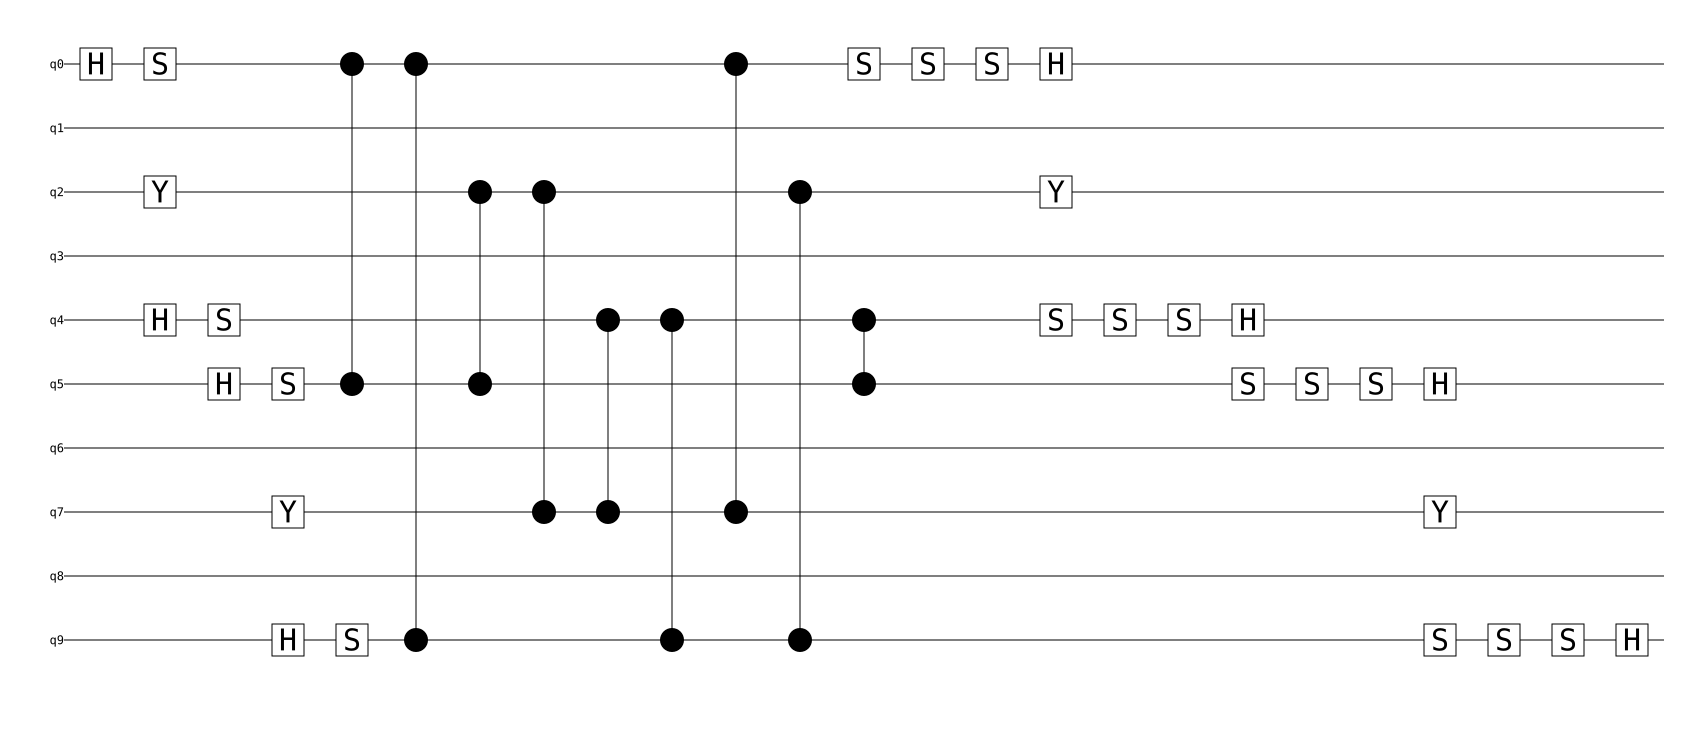

In [167]:
my_circuit_10_stim = stim.Circuit()

for gate, qs in my_circuit_10:
   if gate == "SWAP" and qs[0] == qs[1]:
      continue

   if gate in ["Z", "H", "X", "S", "Y"]:
      my_circuit_10_stim.append(gate, qs)
      continue

   my_circuit_10_stim.append(gate, [q for q in qs])



display(my_circuit_10_stim.diagram(type="timeline-svg"))

In [168]:
combined_generators_after_circuit = [conjugate_stabilizer_by_circuit(s, my_circuit_10_stim) for s in combined_generators]

print("generators:")
for i in range(len(combined_generators_after_circuit)):
   print("before  =  " + str(combined_generators[i]) + "    AFTER =   " + str(combined_generators_after_circuit[i]))

combined_generators_span = stabilizer_span(combined_generators)

for s in combined_generators_after_circuit:
    if str(s) in combined_generators_span:
        print(s, "YES")
    else:
        print(s, "NO")

generators:
before  =  +ZZX_X_____    AFTER =   +ZZX_X_____
before  =  +_____ZZX_X    AFTER =   +_____ZZX_X
before  =  +XZZX______    AFTER =   +XZZX______
before  =  +_____XZZX_    AFTER =   +_____XZZX_
before  =  +_XZZX_____    AFTER =   +_XZZX_____
before  =  +______XZZX    AFTER =   +______XZZX
before  =  +X_XZZ_____    AFTER =   +X_XZZ_____
before  =  +_____X_XZZ    AFTER =   +_____X_XZZ
+ZZX_X_____ YES
+_____ZZX_X YES
+XZZX______ YES
+_____XZZX_ YES
+_XZZX_____ YES
+______XZZX YES
+X_XZZ_____ YES
+_____X_XZZ YES


In [178]:
num_anc = 9

I_anc = stim.PauliString("I" * num_anc)

combined_generators_extended = []

# old stabilizers extended by identities on 9 ancillas
for s in combined_generators:
    combined_generators_extended.append(s + I_anc)

# ancilla |0> stabilizers: Z on each ancilla
for j in range(num_anc):
    anc_stab = "I" * 10 + "I" * j + "Z" + "I" * (num_anc - j - 1)
    combined_generators_extended.append(stim.PauliString(anc_stab))

# old logical operators extended by identities
logical_XI_extended = logical_XI + I_anc
logical_ZI_extended = logical_ZI + I_anc
logical_IX_extended = logical_IX + I_anc
logical_IZ_extended = logical_IZ + I_anc

# products of logicals
logical_XX_extended = logical_XI_extended * logical_IX_extended
logical_ZZ_extended = logical_ZI_extended * logical_IZ_extended
logical_XZ_extended = logical_XI_extended * logical_IZ_extended
logical_ZX_extended = logical_ZI_extended * logical_IX_extended

In [186]:
ancilla_dict = {
    (0,5): 10,
    (0,9): 11,
    (2,5): 12,
    (2,7): 13,
    (4,7): 14,
    (4,9): 15,
    (0,7): 16,
    (2,9): 17,
    (4,5): 18
}

def replace_cz_with_parity_s_gadget(circuit):
    new_circ = []

    for gate, qs in circuit:
        if gate == "CZ":
            a, b = qs[0], qs[1]
            new_circ.extend([
                ("S", [qs[0]]), ("S", [qs[0]]), ("S", [qs[0]]),
                ("S", [qs[1]]), ("S", [qs[1]]), ("S", [qs[1]]),
                ("S", [ancilla_dict[tuple(qs)]])
            ])
        else:
            new_circ.append((gate, qs))

    return new_circ

my_circuit_19 = replace_cz_with_parity_s_gadget(my_circuit_10)

print(my_circuit_19)

for k,v in ancilla_dict.items():
   my_circuit_19.insert(0, ("CNOT", [k[0], v]))
   my_circuit_19.insert(0, ("CNOT", [k[1], v]))
   my_circuit_19.append(("CNOT", [k[0], v]))
   my_circuit_19.append(("CNOT", [k[1], v]))


[('H', [0]), ('S', [0]), ('Y', [2]), ('H', [4]), ('S', [4]), ('H', [5]), ('S', [5]), ('Y', [7]), ('H', [9]), ('S', [9]), ('S', [0]), ('S', [0]), ('S', [0]), ('S', [5]), ('S', [5]), ('S', [5]), ('S', [10]), ('S', [0]), ('S', [0]), ('S', [0]), ('S', [9]), ('S', [9]), ('S', [9]), ('S', [11]), ('S', [2]), ('S', [2]), ('S', [2]), ('S', [5]), ('S', [5]), ('S', [5]), ('S', [12]), ('S', [2]), ('S', [2]), ('S', [2]), ('S', [7]), ('S', [7]), ('S', [7]), ('S', [13]), ('S', [4]), ('S', [4]), ('S', [4]), ('S', [7]), ('S', [7]), ('S', [7]), ('S', [14]), ('S', [4]), ('S', [4]), ('S', [4]), ('S', [9]), ('S', [9]), ('S', [9]), ('S', [15]), ('S', [0]), ('S', [0]), ('S', [0]), ('S', [7]), ('S', [7]), ('S', [7]), ('S', [16]), ('S', [2]), ('S', [2]), ('S', [2]), ('S', [9]), ('S', [9]), ('S', [9]), ('S', [17]), ('S', [4]), ('S', [4]), ('S', [4]), ('S', [5]), ('S', [5]), ('S', [5]), ('S', [18]), ('S', [0]), ('S', [0]), ('S', [0]), ('H', [0]), ('Y', [2]), ('S', [4]), ('S', [4]), ('S', [4]), ('H', [4]), ('S', 

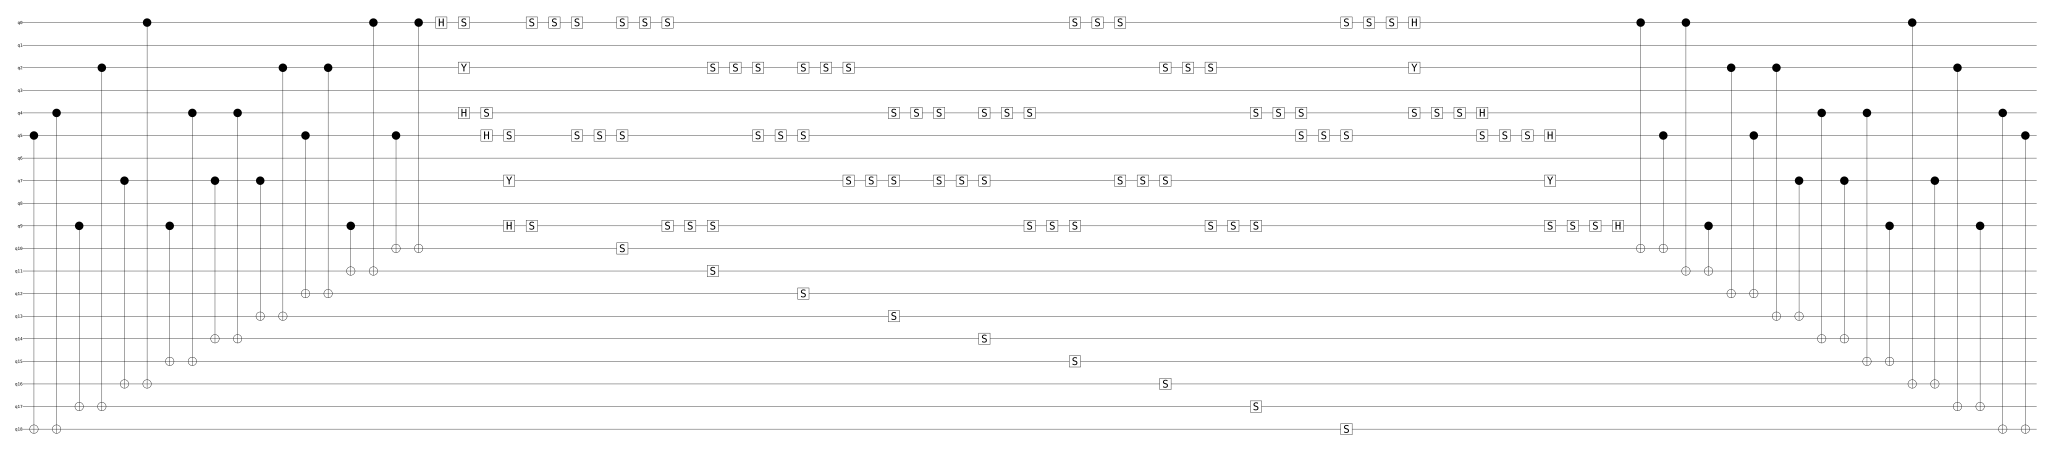

In [182]:
my_circuit_19_stim = stim.Circuit()

for gate, qs in my_circuit_19:
   if gate in ["Z", "H", "X", "S", "Y"]:
      my_circuit_19_stim.append(gate, qs)
      continue

   my_circuit_19_stim.append(gate, [q for q in qs])

display(my_circuit_19_stim.diagram(type="timeline-svg"))

In [183]:
combined_generators_extended_after_circuit = [conjugate_stabilizer_by_circuit(s, my_circuit_19_stim) for s in combined_generators_extended]

print("generators:")
for i in range(len(combined_generators_extended_after_circuit)):
   print("before  =  " + str(combined_generators_extended[i]) + "    AFTER =   " + str(combined_generators_extended_after_circuit[i]))

combined_generators_extended_span = stabilizer_span(combined_generators_extended)

for s in combined_generators_extended_after_circuit:
    if str(s) in combined_generators_extended_span:
        print(s, "YES")
    else:
        print(s, "NO")

generators:
before  =  +ZZX_X______________    AFTER =   -YZX_Y_____XXZZZZXZZ
before  =  +_____ZZX_X_________    AFTER =   -_____YZX_YXZXZZZZZX
before  =  +XZZX_______________    AFTER =   -YZZX_Z_Z_ZZZ____Z__
before  =  +_____XZZX__________    AFTER =   -Z_Z_ZYZZX_Z_Z_____Z
before  =  +_XZZX______________    AFTER =   -_XZZYZ_Z_Z____ZZ__Z
before  =  +______XZZX_________    AFTER =   -Z_Z_Z_XZZY_Z___Z_Z_
before  =  +X_XZZ______________    AFTER =   -Y_XZY_____ZZZZXXZZX
before  =  +_____X_XZZ_________    AFTER =   -_____Y_XZYZXZZZXZXZ
before  =  +__________Z________    AFTER =   -X____X____ZXX___X_X
before  =  +___________Z_______    AFTER =   -X________XXZ___XXX_
before  =  +____________Z______    AFTER =   -_____X____X_Y_____X
before  =  +_____________Z_____    AFTER =   +_____________Z_____
before  =  +______________Z____    AFTER =   -____X_________YX__X
before  =  +_______________Z___    AFTER =   -____X____X_X__XZ_XX
before  =  +________________Z__    AFTER =   -X_________XX____Y_

In [ ]:
logical_IX_extended_after = str(conjugate_stabilizer_by_circuit(logical_IX_extended, my_circuit_11_stim))
logical_IZ_extended_after = str(conjugate_stabilizer_by_circuit(logical_IZ_extended, my_circuit_11_stim))


print("logical_IX_extended_after    = ", logical_IX_extended_after)
print("logical_IX_extended          = ", logical_IX_extended)
print("logical_IZ_extended_after    = ", logical_IZ_extended_after)
print("logical_IZ_extended          = ", logical_IZ_extended)
